# 2D Flat Notebook
Calculates energy to flatten a shell.

In [3]:
import numpy as np
import os
import sys
import gzip
import subprocess
import importlib
import pathlib
import shutil
import yaml
import datetime
import pytz
import time
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D
import utils.run_manager as rm
# from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
version = "v1"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{versionpath}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

# rm.print_header(version)
# rm.make_simpaths_file(JOBDIR,JOB)     # make empty status file for this job

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

# def extents(result,frame=0):
#     Nbeads = int(np.max(result.dump_id[frame])/2)
#     botmask = result.dump_id[frame]<=(Nbeads)
#     topmask = result.dump_id[frame]>(Nbeads)
#     ytopavg = np.mean(result.dump_y[frame][topmask])
#     ybotavg = np.mean(result.dump_y[frame][botmask])
#     xmax = np.max(result.dump_x[frame])
#     xmin = np.min(result.dump_x[frame])
#     x = xmax-xmin
#     y = ytopavg-ybotavg
#     return (x,y)

In [11]:
dcore = 1.0    # hard core diameter of beads 
dimension = 2
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
t0 = 0.6 * dcore    # structural thickness
wx = 4.9 * dcore    # shell width (arclength along midline)
r0 = 6.5 * dcore   # set to "flat" for particles with zero curvature
Nbeads = 50    # number of beads per layer (2Nbeads is beads per curvamer)
fraction = 1/3    # middle patch of beads has width = fraction * wx

if r0 == "flat":
    k_0 = 0
else:
    k_0 = 1/r0

### Elasticity
# kh = kh_list[j]
nu = 0.3
d = wx/(Nbeads-1)   # bead spacing
alpha = t0/d
kvkh = 2*(1-alpha**2 * nu)/(alpha**2 - nu)
kckh = nu*(1 + alpha**2)/(alpha**2 - nu)

kvkh = 1
kckh = 1
d

0.1

In [12]:
25*4.35

108.74999999999999

In [13]:
kckh

1

In [14]:
kvkh

1

(0.0, 2.0)

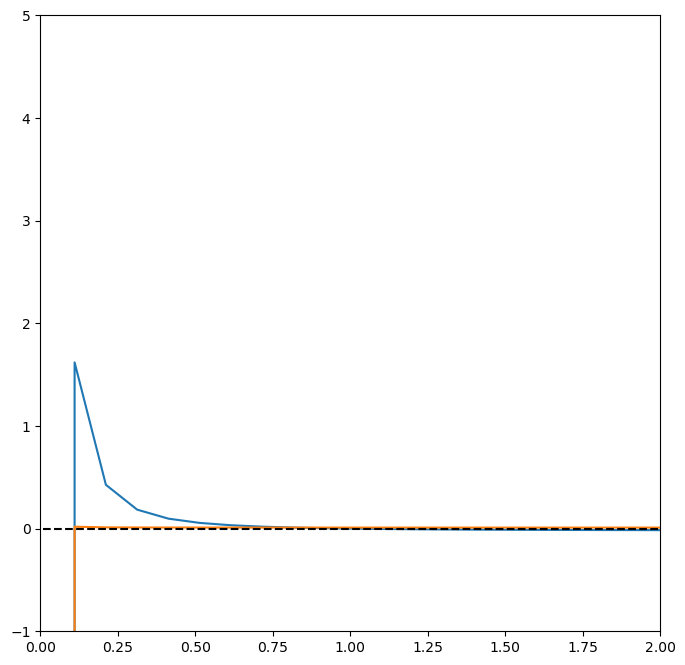

In [15]:
nu = 0.01
tlist = np.linspace(0.01,10,100)
fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(tlist,2*(1-(tlist/d)**2 * nu)/((tlist/d)**2 - nu),label = "kvkh")
ax.plot(tlist,nu*(1 + (tlist/d)**2)/((tlist/d)**2 - nu),label = "kckh")
ax.plot(tlist,np.zeros(len(tlist)),"k--")
ax.set_ylim(-1,5)
ax.set_xlim(0,2)

In [16]:
kvkh

1

In [17]:
kckh

1

# Run emin simulations

In [24]:
r0_list = [r0]
kh_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100] #np.arange(100,1000+1,100).tolist() 

rm.print_header(version)

jobcounter = 0
for i in range(len(r0_list)):   
    simcounter = 0
    jobcounter += 1

    print("#####################################\n")
    print(f"Setting up job {jobcounter}...")

    series_simpaths = [] # append simpaths that will run in series for each job (i.e. different kh values)

    for j in range(len(kh_list)):  

        simcounter += 1

        print(f"----Preparing simulation {simcounter}...")

        ##### PARTICLE #####
        ### Geometry
        dimension = 2
        dcore = 1.0    # hard core diameter of beads 
        t0 = 0.6     # structural thickness
        wx = 46 #4.9     # shell width (arclength along midline)
        r0 = r0_list[i]   # set to "flat" for particles with zero curvature
        Nbeads = 130 #15    # number of beads per layer (2Nbeads is beads per curvamer)
        fraction = 1/3    # middle patch of beads has width = fraction * wx

        if r0 == "flat":
            k_0 = 0
        else:
            k_0 = 1/r0

        ### Elasticity
        kh = kh_list[j]
        nu = 0.3
        d = wx/(Nbeads-1)   # bead spacing
        alpha = t0/d
#         kvkh = 1 #(12 * t0**2 * (1-nu)) / (-3 * d**2 * (1-nu) + 4 * t0**2) #(12 * t0**2 * (1-nu)) / (3 * d**2 * (1-nu) - 4 * t0**2)
#         kckh = 1 #(3 * (d**2 + t0**2) * (1-nu))/(2 * t0**2)
        kvkh = 2*(1-alpha**2 * nu)/(alpha**2 - nu)
        kckh = nu*(1 + alpha**2)/(alpha**2 - nu)
        
#         Nbeads = 45

        ### Interactions
        pair_ints = "none" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
        soft_ints = False
        sigma = 0
        epsilon = 0
        shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
        ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
        wcacut = dcore    # cutoff distance for repulsive wca potential
        softsigma = 5*sigma
        softepsilon = 5e-8 * epsilon
        softshift = 0 #softcore - 2**(1/6)*softsigma
        softcut = 2**(1/6) * softsigma

        ##### SIMULATION #####
        config = "stacked" #"dispersed" or "stacked"
        simtype = "emin"
        datascript = "stack"    # script to make data file, NO .py EXTENSION, "stack", "load", or "lattice"
        nshells = 1
        datagz = False
        trajgz = False
        dumpbonds = False    # whether to calculate and dump bond data
        screen = False    # output lammps log to screen


        ### Stacked config settings
        k_i = 0 * k_0    # curvature of bottom shell in stack
        xlo = -2*wx
        xhi = 2*wx
        ylo = -4*t0
        yhi = 4*t0
        zlo = -0.5
        zhi = 0.5

        ### Dispersed config settings
        # phi = 0.01    # concentration of molecules (area fraction) - only for MD
        # Nx = 4    # number of particle columns for initial config (applies if simpath_old = "none")
        # Ny = int(nshells/Nx)
        # v0 = wx * (t0 + dcore)
        # lbox = np.sqrt(nshells * v0 / phi)    # side length of (square) sim box to give proper concentration
        # xlo = -lbox/2
        # xhi = lbox/2
        # ylo = -lbox/2
        # yhi = lbox/2
        # zlo = -0.5
        # zhi = 0.5

        ### Dynamics/Minimization Settings
        minstyle = "hftn"
        etol = 1e-14
        maxiter = 100000

#         Tstart = 0
#         Tstop = Tstart
#         Tdamp = 1
#         seed = 15298
#         timestep = 0.0005
#         runsteps = 100000

        dumpfreq = maxiter
        thermofreq = 1000


        ##### LOGISTICS #####

        ### Simulation Directories
        delete_existing = True    # if True, deletes simulation directory if it exists before creating again
        load_simpath = False # location of trajectory file to load in (set to False if not loading in state)
        simpath = f"data/{int(dimension)}d/mesh_characteristics/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/elasticity/kvkh-{kvkh:0.3f}-kckh-{kckh:0.3f}/flat/r0-{r0:0.3f}-{minstyle}-{int(np.abs(np.log10(etol)))}/kh-{kh:0.3f}" # path to simulation directory (relative to PROJECT_ROOT)

        ### Computation
        computer = "local"
    #     computer = "unity"
        nnodes = 1
        mem = 1 #GB
        tlim_hrs = 0
        tlim_min = 10
        partition = "cpu-preempt"    # requested partition
        jobname = os.path.splitext(os.path.basename(sys.argv[0]))[0]
        requested_walltime = f'{tlim_hrs:02d}:{tlim_min:02d}:00'
        tbuffer = 1 # stop lammps tbuffer minutes before walltime is exceeded
                        # any non-zero value means script will auto resubmit until done
                        # zero means no auto resubmission - job stops when done or if time is exceeded
        px = 1    # number of cpus along x
        py = 1
        pz = 1
        gridfreq = 10000    # check cpu partitioning of simbox every gridfreq steps
        thresh = 1.01    # threshold imbalance to repartition simbox
        maxrestarts = 10    # max number of runs for one job (cluster only, local machine limit is set below to 5)

        # add tstep start variable?


        #################
        ##### SETUP #####
        #################

        print("--------Creating simulation directory...")

        ### Make simulation directory

        if delete_existing == True:
            if os.path.isdir(f"{PROJECT_ROOT}/{simpath}"):
                print("""----------Simulation directory already exists.
    ----------Deleting...""")
                shutil.rmtree(f"{PROJECT_ROOT}/{simpath}")
                print("----------Creating new simulation directory...")

        os.makedirs(f"{PROJECT_ROOT}/{simpath}", exist_ok=True)

#         ### Append simpaths to job status file and to series_simpaths
#         print("--------Adding simulation directory to job simpaths file...")
#         rm.update_simpaths_file(JOBDIR,JOB,simpath)
        series_simpaths.append(simpath)

        ###############################
        ##### LAMMPS INPUT SCRIPT #####
        ###############################

        print("--------Writing LAMMPS input file...")

        ### Header
        inputcontents = f"""# Coarse-grained shell model - LAMMPS input file

units lj
dimension {dimension}
boundary s s p
atom_style molecular
bond_style harmonic
angle_style none
dihedral_style none
improper_style none

processors {px} {py} {pz} grid onelevel

comm_style tiled
"""

        if datagz==True:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps.gz"

"""
        else:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps"

"""

        ### Interactions
        if pair_ints == "none":
            inputcontents += f"""
pair_style none
"""
        elif pair_ints == "repulsive":
            inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
\n
"""

        else:
            if soft_ints == True:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 3 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 1 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 4 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 2 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
"""
            else:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
"""


            if pair_ints == "1patch":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
"""
            elif pair_ints == "patchy":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
\n
"""

            elif pair_ints == "attractive":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
pair_modify shift yes
\n
"""

        
        # Fixes
        if dimension == 2:
            inputcontents += "fix 0 all enforce2d"
        if simtype == "md":
            inputcontents += f"""
fix 1 all langevin {Tstart} {Tstop} {Tdamp} {seed}
fix 2 all nve
"""           
    #         inputcontents += f"""
    # fix 3 all rigid molecule
    # fix 4 all setforce NULL 0.0 NULL
    # fix 4 all setforce 0.0 0.0 0.0

    # group redge id {Nbeads:g} {2*Nbeads:g}
    # fix 5 redge setforce {force:f} 0.0 0.0
    # fix 5 redge addforce {force:f} 0.0 0.0
    # group ledge id {1:g} {Nbeads+1:g}
    # fix 6 ledge setforce {-force:f} 0.0 0.0
    # fix 6 ledge addforce {force:f} 0.0 0.0"""

#             inputcontents += f"""
# group redge id {Nbeads:g} {2*Nbeads:g}
# fix 5 redge addforce {force:f} 0.0 0.0
# group ledge id {1:g} {Nbeads+1:g}
# fix 6 ledge addforce -{force:f} 0.0 0.0
# """

        if simtype == "emin":
            inputcontents += f"""
fix 4 all setforce NULL 0.0 NULL
"""

        inputcontents += f"""
fix 7 all balance {gridfreq} {thresh} rcb

neigh_modify exclude molecule/intra all every 5 delay 0 check yes
# special_bonds lj 0.0 0.0 0.0

thermo_style custom step etotal ke pe epair ebond temp press
thermo {thermofreq}
thermo_modify norm no
"""
        
        if dumpbonds == True:
            inputcontents += f"""
compute btype all property/local btype
compute batom1 all property/local batom1
compute batom2 all property/local batom2
compute bdist all bond/local dist
compute bpot all bond/local engpot
dump 2 all local {dumpfreq} bonds.dump.gz index c_btype c_batom1 c_batom2 c_bdist c_bpot
"""
    #     fdata.write("\ndump 1 all custom {} {}/trajectory.dump mol id type x y z".format(dumpfreq,simpath))

        if trajgz==True:
            inputcontents += f"""
dump 1 all custom/gz {dumpfreq} trajectory${{stage}}.dump.gz mol id type x y z
dump_modify 1 append no sort id
"""
        else:
            inputcontents += f"""
dump 1 all custom {dumpfreq} trajectory${{stage}}.dump mol id type x y z
dump_modify 1 append no sort id
"""

        if simtype == "md":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
timestep {timestep}
run {runsteps} upto
write_restart restart.final
"""
        elif simtype == "emin":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
min_style {minstyle}
minimize {etol} 0.0 {maxiter} {10*maxiter}
write_restart restart.final
"""        

        # Write LAMMPS input file
        with open(f"{PROJECT_ROOT}/{simpath}/in.lammps", "w") as f:
            f.write(inputcontents)



        ###############################
        ##### WRITE METADATA FILE #####
        ###############################

        print("--------Writing metadata file...")

        params = {

            'particle':{
                'geometry':{
                    'dimension':dimension,
                    'dcore':dcore,
                    't0':t0,
                    'wx':wx,
                    'r0':r0,
                    'Nbeads':Nbeads,
                    'fraction':fraction
                },
                'elasticity':{
                    'nu':nu,
                    'kh':kh,
                    'kckh':kckh,
                    'kvkh':kvkh
                },
                'interactions':{
                    'pair_ints':pair_ints,
                    'soft_ints':int(soft_ints),
                    'sigma':sigma,
                    'epsilon':epsilon,
                    'shift':shift,
                    'ljcut':ljcut,
                    'wcacut':wcacut,

                },
            },

            'simulation':{
                'simtype':simtype,
                'config':config,
                'nshells':nshells,
                'datascript':datascript,
                'xlo':float(xlo),
                'xhi':float(xhi),
                'ylo':float(ylo),
                'yhi':float(yhi),
                'zlo':float(zlo),
                'zhi':float(zhi),
                'simbox_x':float(xhi-xlo),
                'simbox_y':float(yhi-ylo),
                'simbox_z':float(zhi-zlo),
                'thermofreq':thermofreq,
                'dumpfreq':dumpfreq,
                'datagz':datagz,
                'trajgz':trajgz,
                'dumpbonds':dumpbonds


            },

            'logistics':{
                'computer':computer,
                'jobname':jobname,
                'simpath':simpath,
                'tbuffer':tbuffer,
                'run_counter':0

            }
        }

        if soft_ints == True:
            softparams = {'softsigma':softsigma,'softepsilon':softepsilon,
                    'softshift':softshift,'softcut':softcut}
            params['particle']['interactions'].update(softparams)

        if simtype == "emin":
            eminparams = {'minstyle':minstyle,'etol':etol,'maxiter':maxiter}
            params['simulation'].update(eminparams)

        if simtype == "md":
            mdparams = {'Tstart':Tstart,'Tstop':Tstop,'Tdamp':Tdamp,'seed':seed,
                        'timestep':timestep,'runsteps':runsteps}
            params['simulation'].update(mdparams)

        if config == "dispersed":
            disp_params = {'phi':phi}
            params['simulation'].update(disp_params)

        if config == "stacked":
            stack_params = {'k_i':k_i}
            params['simulation'].update(stack_params)

        if computer != 'local':
            clusterparams = {'nnodes':nnodes,'cpus':px*py*pz,'mem':mem,
                             'partition':partition,'requested_walltime':requested_walltime}
            params['logistics'].update(clusterparams)

        if load_simpath == False:
            loadparams = {'load_simpath':int(load_simpath)}
        else:
            loadparams = {'load_simpath':load_simpath}
        params['logistics'].update(loadparams)


        # Write YAML metadata
        rm.write_metadata(f"{PROJECT_ROOT}/{simpath}",params)


        print(f"----Simulation {simcounter} prepared.")

        ################################
        ##### RUN ON LOCAL MACHINE #####
        ################################

        if computer == "local":
            nrestarts = 1
            maxrestarts = 5    # max number of runs to try to finish job
            restartjob = True
            while (restartjob==True) and (nrestarts<=maxrestarts):
                print(f"Running job {jobcounter} sim {simcounter}.{nrestarts} on local machine...")

                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")
                # on first run create data file
                if meta['logistics']['run_counter'] == 0:
                    make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{version}")
                    t1 = time.time()
                    make_data(simpath)
                    t2 = time.time()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True,sub='logistics',params={'datatime':t2-t1})
                    print(f"Time to create data file: {rm.convert_time(t2-t1)}")

                print("Updating metadata with start time...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",start_times=True)
                print("Executing LAMMPS...")
                ncpus = px*py*pz
                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")    # check what stage to use
                rm.run_lmp(simpath,computer,ncpus,screen,stage = meta['logistics']['run_counter'])
                print("Updating metadata with run info ...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",walltimes=True,steps=True,energies=True)
                if simtype == "emin":
                    result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
                    result.read_log()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",sub="logistics",params = {'stopcriterion':result.why_stop})
                # NEED MD SECTION HERE
                restartjob = rm.check_restart(f"{PROJECT_ROOT}/{simpath}")
                if restartjob:
                    print("Reached walltime limit.  Restarting new run...")
                    nrestarts += 1
                    if nrestarts <= maxrestarts:
                        rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True)
                print("\n#####################################")

            if nrestarts > maxrestarts:
                print(f"Max number of restarts exceeded ({maxrestarts}).")
                print("#####################################")


######################################
######################################

    Coarse-Grained Shell Simulator   
    
        Kyle Thomas Sullivan
       kyltsullivan@umass.edu
       
######################################
######################################

Using curvsim v1

######################################
#####################################

Setting up job 1...
----Preparing simulation 1...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 1 prepared.
Running job 1 sim 1.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.004264116287231445sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 2...
--------Creating simulation directory.

LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 16...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 16 prepared.
Running job 1 sim 16.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.005992889404296875sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS Runtime: 0.0hrs 0.0min 0.1sec
Updating metadata with run info ...

#####################################
----Preparing simulation 17...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 17 prepared.
Running job 1 sim 17.1 on local machine...
Using stack.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data fi

## Read sims and plot

In [25]:
##### PARTICLE #####
### Geometry
dimension = 2
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
t0 = 0.6 * dcore    # structural thickness
wx = 46 #4.9 * dcore    # shell width (arclength along midline)
# r0 = "flat"   # set to "flat" for particles with zero curvature
Nbeads = 130 #15    # number of beads per layer (2Nbeads is beads per curvamer)
fraction = 1/3    # middle patch of beads has width = fraction * wx

### Elasticity
nu = 0.3
d = wx/(Nbeads-1)   # bead spacing
alpha = t0/d
# kvkh = 1 #(12 * t0**2 * (1-nu)) / (-3 * d**2 * (1-nu) + 4 * t0**2) #(12 * t0**2 * (1-nu)) / (3 * d**2 * (1-nu) - 4 * t0**2)
# kckh = 1 #(3 * (d**2 + t0**2) * (1-nu))/(2 * t0**2)
kvkh = 2*(1-alpha**2 * nu)/(alpha**2 - nu)
kckh = nu*(1 + alpha**2)/(alpha**2 - nu)

# Nbeads = 45

minstyle = "hftn"
etol = 1e-14
# r0_list = [34,68]   
# kh_list = "all"   # plot all kh simulations found in mesh directory
# kh_list = np.linspace(1,100,100).tolist()   # only plot these spring constants

r0s = []
khs = []
eflats = []
jobcounter = 0
for i in range(len(r0_list)):   
    r0 = r0_list[i]
    parentsimpath = f"data/{int(dimension)}d/mesh_characteristics/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/elasticity/kvkh-{kvkh:0.3f}-kckh-{kckh:0.3f}/flat/r0-{r0:0.3f}-{minstyle}-{int(np.abs(np.log10(etol)))}" # path to simulation directory (relative to PROJECT_ROOT)
    series_simpaths = [] # append simpaths for plotting (i.e. different kh values)
    
    if kh_list == "all":
        khlist = []
        files = os.listdir(f"{PROJECT_ROOT}/{parentsimpath}")
        for f in files:
            kh = float(f[3:])
            khlist.append(kh)
            series_simpaths.append(f"{parentsimpath}/{f}")
    
    else:
        khlist = kh_list
        for j in range(len(kh_list)):  
            kh  = kh_list[j]
            simpath = f"{parentsimpath}/kh-{kh:0.3f}" # path to simulation directory (relative to PROJECT_ROOT)
            series_simpaths.append(simpath)
    
    r0list = []
    eflatlist = []
    for s in series_simpaths:
        logname = "log.lammps"
        result = ReadSim(f"{PROJECT_ROOT}/{s}")
        result.read_log(logname=logname)
        eflat = result.energyf
        eflatlist.append(eflat)
        r0list.append(r0)
    eflats.append(eflatlist)
    r0s.append(r0list)
    khs.append(khlist)
    
    
# pratios = np.array(pratios)
# strains = np.array(strains)
    

In [26]:
eflats[0][0]

3.41720056076669

Text(0, 0.5, 'Eflat')

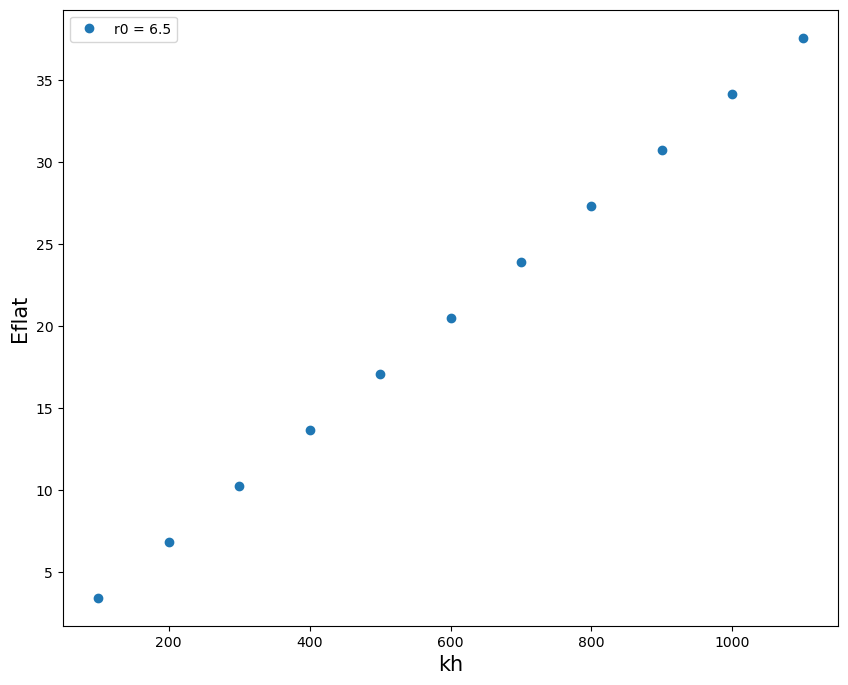

In [27]:

fig, ax = plt.subplots(1,1,figsize=(10,8))
for i in range(len(r0s)):
    ax.plot(np.array(khs[i]),np.array(eflats[i]),"o",label=f"r0 = {r0s[i][0]}")
# ax.set_xlim(0,1.5)
# ax.set_ylim(0,0.5)
ax.legend()
ax.set_xlabel("kh",fontsize=15)
ax.set_ylabel("Eflat",fontsize=15)



In [28]:
i = 0
print(f"r0 = {r0s[i][0]}")
print(f"kh_list = np.array({khs[i]})")
print(f"eflat_list = np.array({eflats[i]})")

r0 = 6.5
kh_list = np.array([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100])
eflat_list = np.array([3.41720056076669, 6.83440112153338, 10.2516016823001, 13.6688022430668, 17.0860028038335, 20.5032033646002, 23.9204039253668, 27.3376044861335, 30.7548050469003, 34.1720056076669, 37.5892061684336])


In [29]:
khs

[[100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100]]

In [30]:
np.array(r0s)[0]

array([6.5, 6.5, 6.5, 6.5, 6.5, 6.5, 6.5, 6.5, 6.5, 6.5, 6.5])

Text(0, 0.5, 'Eflat')

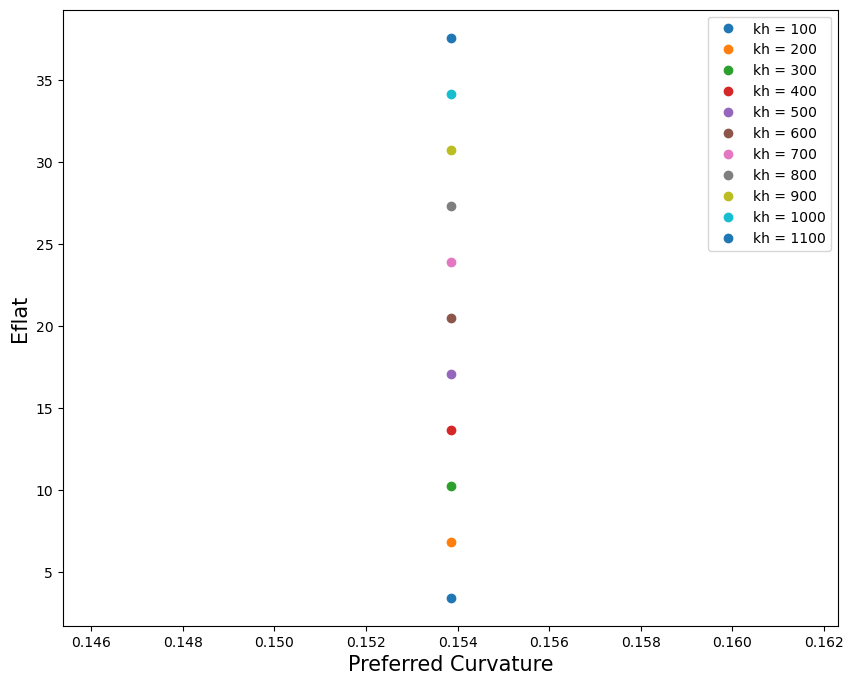

In [31]:
fig, ax = plt.subplots(1,1,figsize=(10,8))
for i in range(len(np.array(r0s)[0])):
    ax.plot(1/(np.array(r0s)[:,i]),np.array(eflats)[:,i],"o",label=f"kh = {khs[0][i]}")
# ax.set_xlim(0,1.5)
# ax.set_ylim(0,0.5)
ax.legend()
ax.set_xlabel("Preferred Curvature",fontsize=15)
ax.set_ylabel("Eflat",fontsize=15)

# Plot atom positions

data/2d/mesh_characteristics/wx-46.000-t0-0.600-Nbeads-130/elasticity/kvkh-0.119-kckh-0.454/flat/r0-6.500-hftn-14/kh-1000.000


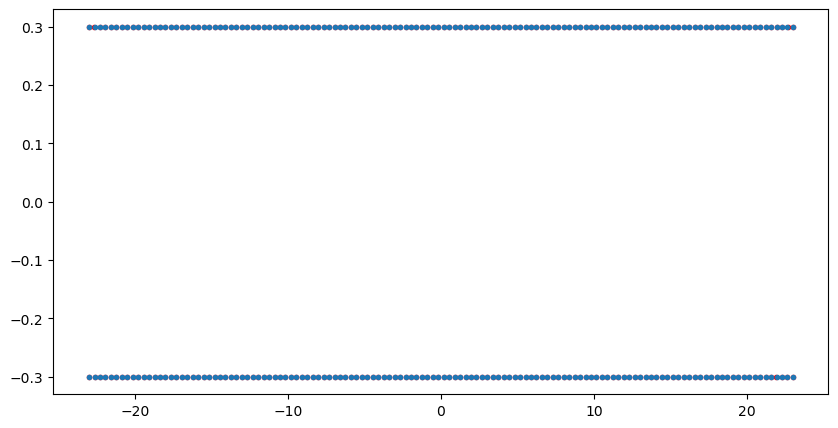

In [32]:
fi = 9    # force index
frame = -1
s = series_simpaths[fi]
print(s)
dumpname = "trajectory1.dump"
result = ReadSim(f"{PROJECT_ROOT}/{s}")
result.read_dump(dumpname=dumpname,readall=True)

fig, ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(result.dump_x[frame],result.dump_y[frame],"r.")
ax.plot(result.dump_x[0],result.dump_y[0],".")
# botmask = result.dump_id[frame]<=(Nbeads)
# topmask = result.dump_id[frame]>(Nbeads)
# ax.plot(result.dump_x[frame][topmask],result.dump_y[frame][topmask],"ko")
# ax.set_xlim(-wx,wx)
# ax.set_ylim(-wx/30,wx/30)